[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cyneuro/SCP/blob/main/3_active.ipynb)

# SCP Step 3 - Active Properties

Check and tune active/channel behavior for a prepared tune directory. This notebook is the primary Step 3 entry point for both local and Colab use.

Workflow:
- **3.0 Environment Setup**: configure local/Colab imports and dependencies.
- **3.1 Select Tune Directory**: choose a Step 1/2 tune to check or tune.
- **3.2 Compile and Load Mechanisms**: compile/load NEURON mechanisms for the selected tune.
- **3.3 Build Cell**: instantiate the cell and review section/area summaries.
- **3.4 ACT Active Tuning Setup**: optionally prepare/run ACT active tuning from a tune-local workspace.
- **3.5 Run Active Protocol**: run positive current steps and compute active-spiking metrics.
- **3.6 Plot Active Trace Check**: review voltage traces and optional current traces.
- **3.7 FI Curve Check**: run and plot a current-frequency curve with optional biological reference points.

Current scope: Step 3 remains manual-first for model edits. Section **3.4** can prepare ACT active-tuning inputs, optionally run ACT modules, and export prediction suggestions without overwriting model files.

Detailed guide: `docs/guides/step_3_active.md`.

In [1]:
# Environment setup: works locally or in Google Colab
%load_ext autoreload
%autoreload 2

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# User-editable only when running in a fresh Colab or unusual local layout.
SCP_REPO_URL = os.environ.get("SCP_REPO_URL", "https://github.com/cyneuro/SCP.git")
SCP_REPO_BRANCH = os.environ.get("SCP_REPO_BRANCH", "") or None
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
AUTO_CLONE_REPO = os.environ.get("SCP_AUTO_CLONE", "1" if IN_COLAB else "0") not in {"0", "false", "False"}
INSTALL_DEPS = None  # None = install automatically in Colab, do not install locally.
SCP_REPO_DIR = Path(os.environ.get("SCP_REPO_DIR", "/content/SCP" if IN_COLAB else str(Path.cwd() / "SCP")))


def _looks_like_scp_repo(path: Path) -> bool:
    return (path / "modules").is_dir() and (path / "run_pipeline.py").is_file()


# Minimal pre-import bootstrap. Fresh Colab cannot import SCP helpers until the repo exists.
repo_root = None
env_root = os.environ.get("SCP_ROOT")
if env_root and _looks_like_scp_repo(Path(env_root).expanduser()):
    repo_root = Path(env_root).expanduser().resolve()
else:
    start = Path.cwd().resolve()
    candidates = list((start, *start.parents))
    for base in (start, start.parent):
        try:
            candidates.extend(child for child in base.iterdir() if child.is_dir())
        except Exception:
            pass
    for candidate in candidates:
        if _looks_like_scp_repo(candidate):
            repo_root = candidate.resolve()
            break

if repo_root is None:
    if not AUTO_CLONE_REPO:
        raise FileNotFoundError("Could not find SCP. Set SCP_ROOT or enable SCP_AUTO_CLONE=1.")
    clone_url = SCP_REPO_URL
    token = os.environ.get("SCP_GIT_TOKEN") or os.environ.get("SCP_GITHUB_TOKEN") or os.environ.get("GITHUB_TOKEN")
    if token and clone_url.startswith("https://") and "@" not in clone_url:
        clone_url = clone_url.replace("https://", f"https://{token}@", 1)
    clone_cmd = ["git", "clone", "--depth", "1"]
    if SCP_REPO_BRANCH:
        clone_cmd += ["--branch", SCP_REPO_BRANCH]
    clone_cmd += [clone_url, str(SCP_REPO_DIR)]
    subprocess.check_call(clone_cmd)
    repo_root = SCP_REPO_DIR.resolve()

os.environ["SCP_ROOT"] = str(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from modules.notebooks.bootstrap import ensure_notebook_dependencies, is_colab
from modules import run_sim

ensure_notebook_dependencies(install_deps=INSTALL_DEPS)

print("Runtime:", "Colab" if is_colab() else "local")
print("SCP repo:", repo_root)

Runtime: local
SCP repo: /home/hrbncv/SCP


--No graphics will be displayed.


## 3.1 Select Tune Directory

Choose a tune prepared by Step 1 and passively checked/tuned by Step 2 when applicable.

Quick guide:
- `cell_name`: cell folder under `cells/`.
- `tune_name`: tune folder under `cells/<cell>/tunes/`.
- `tunes_parent`: normally `tunes`.
- `tune_dir_override`: optional direct path; overrides `cell_name`/`tune_name` when set.

The notebook preserves `cwd = tune_dir` after this cell for compatibility with the current active-sweep helpers.

In [2]:
cell_name = "PV"
tune_name = "tuned"
tunes_parent = "tunes"
tune_dir_override = None  # optional absolute/relative path; overrides cell/tune settings

from modules.tuning import prepare_tuning_notebook_context

context = prepare_tuning_notebook_context(
    cell_name=cell_name,
    tune_name=tune_name,
    tunes_parent=tunes_parent,
    tune_dir_override=tune_dir_override,
    repo_root=repo_root,
    require_compiled_modfiles=False,  # next cell compiles/loads mechanisms when needed
    require_synapse_config=False,
)

tune_dir = context.tune_dir
cell_config = context.cell_config
sim_config = context.sim_config

os.chdir(tune_dir)
print("CWD:", Path.cwd())

SCP repo: /home/hrbncv/SCP
Tune dir: /home/hrbncv/SCP/cells/PV/tunes/tuned
Cell: PV | Tune: tuned
Cell loader: allen_manifest
Soma diameter multiplier: 6.0
Step 1 validation: ok
CWD: /home/hrbncv/SCP/cells/PV/tunes/tuned


## 3.2 Compile and Load Mechanisms

Compile the tune's `modfiles/` when compiled mechanisms are missing, then load the mechanism library into the current NEURON session.

Quick guide:
- `RECOMPILE_MODFILES = False`: reuse existing compiled mechanisms when possible.
- `RECOMPILE_MODFILES = True`: rebuild from scratch after editing `.mod` files.
- `LOAD_COMPILED_DLL = True`: load mechanisms into this kernel before building/running the cell.

In [3]:
RECOMPILE_MODFILES = False
LOAD_COMPILED_DLL = True

from neuron import h
from modules.setup.mechanisms import compile_modfiles

mechanism_summary = compile_modfiles(
    tune_dir,
    recompile=RECOMPILE_MODFILES,
    load_dll=LOAD_COMPILED_DLL,
)
h.load_file("stdrun.hoc")
print(json.dumps(mechanism_summary, indent=2))

{
  "modfiles_dir": "/home/hrbncv/SCP/cells/PV/tunes/tuned/modfiles",
  "compiled_dir": "/home/hrbncv/SCP/cells/PV/tunes/tuned/modfiles/x86_64",
  "dll": "/home/hrbncv/SCP/cells/PV/tunes/tuned/modfiles/x86_64/.libs/libnrnmech.so",
  "compiled_now": false,
  "nrnivmodl": "/home/hrbncv/miniconda3/envs/scp-py311/bin/nrnivmodl",
  "loaded": true,
  "dll_preloaded": false
}


## 3.3 Build Cell

Build the NEURON cell from the selected tune and review the section/area summary before running active checks.

There are no required user options in this cell. If the cell fails to build, return to Step 1 validation or inspect the selected model files/configs.

In [4]:
from modules.tuning import (
    build_tuning_cell,
    section_summary,
    soma_area_cm2,
    total_area_cm2,
)
from modules.notebooks.helpers import build_cell_for_notebook

cell_config_for_build = context.cell_config
soma_diam_multiplier = float(cell_config_for_build["tuning"]["soma_diam_multiplier"])
cell = build_tuning_cell(context)
cell_summary = section_summary(cell)
computed_soma_area_cm2 = soma_area_cm2(cell)
computed_total_area_cm2 = total_area_cm2(cell)

print("Cell built successfully.")
print("Soma diameter multiplier:", soma_diam_multiplier)
print("Soma area (cm²):", computed_soma_area_cm2)
print("Total area (cm²):", computed_total_area_cm2)
print("Section summary:")
for key, value in cell_summary.items():
    print(f"  {key}: {value}")

/home/hrbncv/miniconda3/envs/scp-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport


na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                           ^


Loaded Allen cell for 'PV' from manifest.json, model_type='Biophysical - perisomatic', soma_diam_multiplier=6.0, Vinit=-71.0, loader=legacy:Biophysical - perisomatic/allensdk_default
Cell built successfully.
Soma diameter multiplier: 6.0
Soma area (cm²): 4.017876017303496e-05
Total area (cm²): 6.182693387308235e-05
Section summary:
  soma: 1
  dend: 41
  apic: 0
  axon: 2
  all_sections: 44
  total_area_um2: 6182.693387308234


## 3.4 ACT Active Tuning Setup (Optional)

This section adapts the selected SCP tune into ACT's active-optimizer API without writing project files into the ACT repo.

Workflow:
- **3.4.1 Controls and target data**: choose whether to use ACT and define FI or trace targets.
- **3.4.2 Cell adapter and module settings**: define ACT-facing channel names, current protocol, and module bounds.
- **3.4.3 Prepare workspace**: generate `act_workspace/`, `cell_builder.py`, `target_sf.csv`, and `act_active_config.json`.
- **3.4.4 Run modules**: optionally run LTO, spiking, bursting, or all modules from the notebook.
- **3.4.5 Review/evaluate predictions**: inspect suggested conductances and optionally run temporary FI evaluation.

All generated files stay inside `cells/<CELL>/tunes/<TUNE>/act_workspace/`. The same workspace can be run from the terminal with `python scripts/run_act_active.py --cell ... --tune ... --run`.


### 3.4.1 Controls and Target Data

Set `USE_ACT_ACTIVE_TUNING = True` only when you want to prepare or run ACT. By default, this section is skipped and Step 3 continues with manual active checks.

Step 3 uses the same `target_config.json` source-mode contract as Step 2:
- `manual`: use `manual.fi_curve.currents_pA` / `manual.fi_curve.rates_Hz`, or `manual.fi_curve.csv`.
- `traces`: use `traces.active.file` as an ACT-compatible `.npy` trace target.
- `allen_nwb`: extract FI targets from an Allen/ADB `.nwb` file using `allen_nwb.active` settings.

Notebook overrides are optional. Leave the variables below as `None` to use `target_config.json`. No hidden fallback targets are used; if ACT is enabled, the selected target source must be complete.

Resolved ACT target modes:
- `fi_arrays`: manual FI current/rate arrays.
- `fi_csv`: manual FI CSV file.
- `allen_nwb`: Allen/ADB NWB FI extraction.
- `trace_npy`: ACT-compatible trace target file.


Active trace target note:
- `traces.active` is currently an ACT pass-through target, not a generic trace importer.
- Required fields for current support: `target_source.mode = "traces"`, `traces.active.format = "npy"`, and `traces.active.file = "<path>.npy"`.
- The `.npy` file must be shaped like ACT active target data: `(n_trials, n_timepoints, n_columns)` with column `0` as membrane voltage in mV and column `1` as injected current in nA. ACT uses those two columns to compute summary features.
- ACT's current feature extractor assumes samples are effectively 1 ms apart for spike-frequency calculations. If your traces use another timestep, prefer `manual.fi_curve` arrays/CSV or `allen_nwb` until SCP adds a stable active-trace conversion path.
- The scaffolded `traces.active` timing/threshold fields are reserved for future SCP-managed trace conversion; the current ACT mode only verifies that the `.npy` file exists and passes it to ACT.

For Allen/ADB data, set `target_source.mode` to `"allen_nwb"` and `allen_nwb.file` in `target_config.json`, or temporarily set `ACT_TARGET_MODE = "allen_nwb"` and `ACT_NWB_PATH` below. The preparation step writes ACT's `target_sf.csv` and a review-friendly `allen_nwb_fi_curve.csv` in `act_workspace/`.


In [5]:
from modules.tuning import resolve_active_tuning_targets

USE_ACT_ACTIVE_TUNING = False
RUN_ACT_MODULES = False
EVALUATE_ACT_PREDICTIONS = False
OVERWRITE_ACT_OUTPUTS = False

ACT_MODULE_TO_RUN = "all"  # "all", "lto", "spiking", or "bursting"
ACT_WORKSPACE = context.tune_dir / "act_workspace"

# Leave these as None to use cell_configs/target_config.json.
ACT_TARGET_MODE = None        # None -> derive from target_source.mode; or "fi_arrays", "fi_csv", "allen_nwb", "trace_npy"
ACT_FI_CURRENTS_PA = None     # e.g. [0, 50, 100, 150, 200]
ACT_FI_FREQUENCIES_HZ = None  # e.g. [0, 2, 8, 16, 24]
ACT_FI_CSV_PATH = None        # e.g. "act_workspace/my_fi_curve.csv"
ACT_TRACE_NPY_PATH = None     # e.g. "act_workspace/target_traces.npy"
ACT_NWB_PATH = None           # e.g. "484635027_ephys.nwb"

active_target_resolution = resolve_active_tuning_targets(
    context=context,
    target_mode=ACT_TARGET_MODE,
    fi_currents_pA=ACT_FI_CURRENTS_PA,
    fi_frequencies_hz=ACT_FI_FREQUENCIES_HZ,
    fi_csv_path=ACT_FI_CSV_PATH,
    trace_npy_path=ACT_TRACE_NPY_PATH,
    nwb_path=ACT_NWB_PATH,
    require_target=USE_ACT_ACTIVE_TUNING,
)

target_config = active_target_resolution.target_config
ACT_TARGET_MODE = active_target_resolution.target_mode
ACT_FI_CURRENTS_PA = active_target_resolution.fi_currents_pA
ACT_FI_FREQUENCIES_HZ = active_target_resolution.fi_frequencies_hz
ACT_FI_CSV_PATH = active_target_resolution.fi_csv_path
ACT_TRACE_NPY_PATH = active_target_resolution.trace_npy_path
ACT_NWB_PATH = active_target_resolution.nwb_path
ACT_NWB_OPTIONS = active_target_resolution.nwb_options

print("Target config:", context.cell_configs_dir / "target_config.json")
print("Target source mode:", active_target_resolution.target_source_mode)
print("Target source:", target_config.get("target_source", "not configured") if target_config else "not found")
print("ACT target mode:", ACT_TARGET_MODE)
print("ACT FI currents pA:", ACT_FI_CURRENTS_PA)
print("ACT FI frequencies Hz:", ACT_FI_FREQUENCIES_HZ)
print("Detected NWB files:", [p.name for p in active_target_resolution.detected_nwb_files])
print("ACT NWB path:", ACT_NWB_PATH)
print("ACT NWB options:", ACT_NWB_OPTIONS)


Target config: /home/hrbncv/SCP/cells/PV/tunes/tuned/cell_configs/target_config.json
Target source mode: manual
Target source: {'mode': 'manual', 'description': 'custom'}
ACT target mode: fi_arrays
ACT FI currents pA: [0.0, 25.0, 50.0, 75.0, 100.0, 125.0, 150.0, 175.0, 200.0, 225.0, 250.0, 275.0, 300.0]
ACT FI frequencies Hz: [0.0, 0.0, 0.0, 0.1, 3.3, 6.2, 12.9, 19.7, 27.9, 35.2, 44.8, 55.5, 57.4]
Detected NWB files: []
ACT NWB path: None
ACT NWB options: {'stimulus_names': ['Long Square'], 'min_current_pA': 0.0, 'max_current_pA': None, 'include_negative_currents': False, 'average_repeats': True, 'spike_threshold_mV': -20.0, 'refractory_ms': 1.0}


### 3.4.2 Cell Adapter and Module Settings

These settings are the ACT-facing contract. Edit them when your model uses different mechanism variable names or different channel groupings.

Defaults follow the current PV/SST ADB examples:
- `lto`: low-threshold/near-threshold channels (`Nap`, `K_T`, `Im`).
- `spiking`: fast spiking channels (`NaTa`, `Kd`).
- `bursting`: calcium/high-threshold potassium channels (`Ca_LVA`, `Ca_HVA`, `Kv2like`, `Kv3_1`).

`ACT_MODULES` is intentionally plain Python data so it can be copied into JSON or used by the CLI workflow.


In [6]:
from modules.tuning import default_act_module_specs

ACT_PASSIVE_NAMES = ["g_pas", "e_pas", "gbar_Ih"]
ACT_ACTIVE_CHANNELS = [
    "gbar_Nap",
    "gbar_Im_v2",
    "gbar_K_T",
    "gbar_NaTa",
    "gbar_Kd",
    "gbar_Ca_LVA",
    "gbar_Ca_HVA",
    "gbar_Kv2like",
    "gbar_Kv3_1",
]

ACT_SIM_PARAMS = {
    "h_v_init": -50.0,
    "h_tstop": 1500.0,
    "h_dt": 0.025,
    "h_celsius": 37.0,
    "ci_delay_ms": 200.0,
    "ci_dur_ms": 1000.0,
    "ci_amps_pA": ACT_FI_CURRENTS_PA,
}

ACT_OPTIMIZER = {
    "n_cpus": 4,
    "random_state": 42,
    "n_estimators": 1000,
    "max_depth": None,
    "train_features": ["spike_frequency", "mean_i"],
    "spike_threshold": -20.0,
    "max_n_spikes": 20,
}

ACT_FILTER = {
    "filtered_out_features": None,  # e.g. ["saturated"] or ["saturated", "no_spikes"]
    "window_of_inspection": [200, 1200],
    "saturation_threshold": -55.0,
}

ACT_MODULES = default_act_module_specs(context.cell_name)

print("ACT modules:")
for module_name, module_spec in ACT_MODULES.items():
    conductances = [item["variable_name"] for item in module_spec.get("conductances", [])]
    print(f"  {module_name}: {conductances}")


ACT modules:
  lto: ['gbar_Nap', 'gbar_K_T', 'gbar_Im_v2']
  spiking: ['gbar_NaTa', 'gbar_Kd']
  bursting: ['gbar_Ca_LVA', 'gbar_Ca_HVA', 'gbar_Kv2like', 'gbar_Kv3_1']


### 3.4.3 Prepare ACT Workspace

This creates the tune-local ACT workspace and writes:
- `cell_builder.py`: importable SCP cell builder for ACT multiprocessing.
- `target_sf.csv`: normalized target FI summary features when using FI target modes.
- `act_active_config.json`: shared config used by this notebook and `scripts/run_act_active.py`.

No ACT modules are run in this preparation step.


In [7]:
if USE_ACT_ACTIVE_TUNING:
    from modules.tuning import prepare_act_active_workspace

    act_workspace_summary = prepare_act_active_workspace(
        repo_root=repo_root,
        tune_dir=context.tune_dir,
        cell_name=context.cell_name,
        tune_name=context.tune_name,
        workspace=ACT_WORKSPACE,
        target_mode=ACT_TARGET_MODE,
        fi_currents_pA=ACT_FI_CURRENTS_PA,
        fi_frequencies_hz=ACT_FI_FREQUENCIES_HZ,
        fi_csv_path=ACT_FI_CSV_PATH,
        trace_npy_path=ACT_TRACE_NPY_PATH,
        nwb_path=ACT_NWB_PATH,
        nwb_stimulus_names=ACT_NWB_OPTIONS["stimulus_names"],
        nwb_include_negative_currents=ACT_NWB_OPTIONS["include_negative_currents"],
        nwb_min_current_pA=ACT_NWB_OPTIONS["min_current_pA"],
        nwb_max_current_pA=ACT_NWB_OPTIONS["max_current_pA"],
        nwb_average_repeats=ACT_NWB_OPTIONS["average_repeats"],
        nwb_spike_threshold_mV=ACT_NWB_OPTIONS["spike_threshold_mV"],
        nwb_refractory_ms=ACT_NWB_OPTIONS["refractory_ms"],
        passive_names=ACT_PASSIVE_NAMES,
        active_channels=ACT_ACTIVE_CHANNELS,
        module_specs=ACT_MODULES,
        sim_params=ACT_SIM_PARAMS,
        optimizer=ACT_OPTIMIZER,
        filter_params=ACT_FILTER,
        overwrite_config=True,
    )
    print(json.dumps(act_workspace_summary, indent=2))
else:
    act_workspace_summary = None
    print("ACT active tuning skipped. Set USE_ACT_ACTIVE_TUNING = True to prepare a workspace.")


ACT active tuning skipped. Set USE_ACT_ACTIVE_TUNING = True to prepare a workspace.


### 3.4.4 Run ACT Modules

Running ACT can be computationally expensive. Keep `RUN_ACT_MODULES = False` while editing settings. When ready, set it to `True` and choose `ACT_MODULE_TO_RUN`.

The equivalent terminal command after preparing the workspace is:

```bash
python scripts/run_act_active.py --cell SST --tune tuned --run --module all
```


In [8]:
if USE_ACT_ACTIVE_TUNING and RUN_ACT_MODULES:
    from modules.tuning import run_act_active_modules

    requested_modules = ACT_MODULE_TO_RUN if ACT_MODULE_TO_RUN == "all" else [ACT_MODULE_TO_RUN]
    act_run_results = run_act_active_modules(
        ACT_WORKSPACE,
        modules=requested_modules,
        n_cpus=ACT_OPTIMIZER.get("n_cpus"),
        overwrite=OVERWRITE_ACT_OUTPUTS,
    )
    print(json.dumps(act_run_results, indent=2, default=str))
elif USE_ACT_ACTIVE_TUNING:
    act_run_results = []
    print("ACT workspace prepared; module execution skipped.")
else:
    act_run_results = []


### 3.4.5 Review Predictions and Optional Evaluation

ACT predictions are suggestions for manual model edits. This notebook does not overwrite model files.

Set `EVALUATE_ACT_PREDICTIONS = True` to run an ACT FI check using saved predictions temporarily, without editing the tune files.


In [9]:
if USE_ACT_ACTIVE_TUNING:
    from modules.tuning import collect_act_predictions

    act_predictions = collect_act_predictions(ACT_WORKSPACE)
    if act_predictions:
        print("Saved ACT predictions:")
        print(json.dumps(act_predictions, indent=2))
    else:
        print("No saved ACT prediction JSON files found yet.")

    if EVALUATE_ACT_PREDICTIONS:
        from modules.tuning import evaluate_act_predictions

        act_eval_results = evaluate_act_predictions(
            ACT_WORKSPACE,
            n_cpus=ACT_OPTIMIZER.get("n_cpus"),
            overwrite=OVERWRITE_ACT_OUTPUTS,
        )
        print("Temporary ACT FI evaluation:")
        print(json.dumps(act_eval_results, indent=2, default=str))
else:
    act_predictions = {}


## 3.5 Run Active Protocol

Run positive current-injection steps and compute active-spiking metrics. This mirrors Step 2.5, but focuses on firing behavior instead of passive-property extraction.

Quick guide:
- `active_sim_params`: current-injection timing and integration settings.
- `active_sim_amps`: current steps in pA.
- `active_spike_threshold_mv`: threshold used for spike peak detection.
- Metrics include spike count/frequency, resting voltage, peak/min voltage, first-spike latency, ISI statistics, and adaptation ratio.
- FI target comparison interpolates within the target FI curve and marks out-of-range currents rather than extrapolating.

After manually editing active/channel values, rerun from **3.3 Build Cell** before rerunning this protocol.

In [10]:
active_sim_params = {
    "stim_amp": -0.1,      # overwritten per amplitude below; nA
    "stim_delay": 200,     # ms
    "stim_dur": 1000,      # ms
    "h_tstop": 1500,       # ms
    "h_dt": 0.025,         # ms
}
active_sim_amps = [150, 300]  # pA
active_spike_threshold_mv = -20.0

import pandas as pd
from modules.tuning import (
    run_active_protocol,
    active_metric_rows,
    compare_fi_targets,
    fi_reference_points_from_config,
    fi_reference_points_from_csv,
    load_target_config,
)

cell = build_tuning_cell(context)
active_records = run_active_protocol(
    cell=cell,
    sim_params=active_sim_params,
    sim_amps=active_sim_amps,
)
active_metrics = active_metric_rows(
    looped_records=active_records,
    sim_params=active_sim_params,
    sim_amps=active_sim_amps,
    threshold_mv=active_spike_threshold_mv,
)

print("Active check metrics:")
for row in active_metrics:
    print(json.dumps(row, indent=2, default=str))

active_target_fi_reference = []
if "active_target_resolution" in globals():
    if active_target_resolution.fi_csv_path:
        active_target_fi_reference = fi_reference_points_from_csv(active_target_resolution.fi_csv_path)
    elif active_target_resolution.fi_reference_points:
        active_target_fi_reference = active_target_resolution.fi_reference_points
if not active_target_fi_reference:
    if "target_config" not in globals():
        target_config = load_target_config(context.tune_dir)
    active_target_fi_reference = fi_reference_points_from_config(target_config)

active_target_comparison = compare_fi_targets(active_metrics, active_target_fi_reference)
if active_target_comparison:
    print()
    print("Active target FI comparison:")
    display(pd.DataFrame(active_target_comparison))
else:
    print()
    print("No target FI reference available for active comparison.")


na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                           ^


Loaded Allen cell for 'PV' from manifest.json, model_type='Biophysical - perisomatic', soma_diam_multiplier=6.0, Vinit=-71.0, loader=legacy:Biophysical - perisomatic/allensdk_default
Active check metrics:
{
  "amp_pA": 150.0,
  "spike_count": 16,
  "spike_frequency_hz": 16.0,
  "rest_voltage_mv": -71.00127569933146,
  "peak_voltage_mv": 25.884432383578556,
  "min_voltage_mv": -104.84534122738863,
  "first_spike_latency_ms": 16.024999999940462,
  "mean_isi_ms": 63.66166666680853,
  "min_isi_ms": 62.57500000022765,
  "isi_cv": 0.010471568436615626,
  "adaptation_ratio": 0.9817333851579817
}
{
  "amp_pA": 300.0,
  "spike_count": 56,
  "spike_frequency_hz": 56.0,
  "rest_voltage_mv": -71.00127569933146,
  "peak_voltage_mv": 29.805204900341543,
  "min_voltage_mv": -104.59082638061264,
  "first_spike_latency_ms": 1.6749999999535135,
  "mean_isi_ms": 18.149090909131274,
  "min_isi_ms": 11.999999999989086,
  "isi_cv": 0.05466163406322727,
  "adaptation_ratio": 1.4979166666734784
}

Active targ

,amp_pA,target_lookup,target_frequency_hz,measured_frequency_hz,delta,abs_delta,pct_error,status
0,150.0,exact,12.9,16.0,3.1,3.1,24.031008,ok
1,300.0,exact,57.4,56.0,-1.4,1.4,-2.439024,ok


## 3.6 Plot Active Trace Check

Plot active current-injection voltage traces and, optionally, recorded currents for one selected amplitude.

Quick guide:
- `PLOT_XLIM` / `PLOT_YLIM`: voltage plot axis limits, or `None` for automatic limits.
- `PLOT_CURRENTS`: include a current subplot when `True`.
- `TRACE_COLOR`: voltage trace color when one current is plotted; multiple currents use distinct Matplotlib colors.
- `CURRENT_AMP`: pA amplitude to use for current traces; `None` uses the last active step.
- `CURRENT_NAMES`: selected current names; empty list auto-selects up to `MAX_AUTO_CURRENTS` recorded currents.
- `EXPORT_TRACE_FIGURE` / `EXPORT_TRACE_CSV`: optional notebook-only diagnostics under `notebook_exports/`.

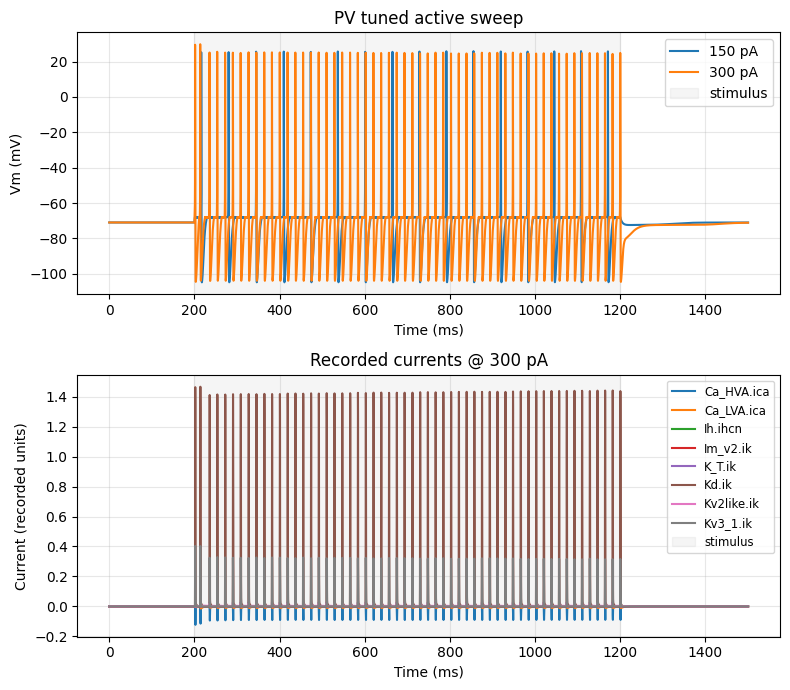

In [11]:
PLOT_XLIM = None             # e.g. (150, 1300)
PLOT_YLIM = None             # e.g. (-90, 50)
TRACE_COLOR = context.cell_config.get("color")  # used only when one current is plotted
PLOT_CURRENTS = True
CURRENT_AMP = None            # None -> active_sim_amps[-1]
CURRENT_NAMES = []            # [] -> auto-select recorded currents; or list names explicitly
CURRENT_XLIM = PLOT_XLIM
CURRENT_YLIM = None
MAX_AUTO_CURRENTS = 8

EXPORT_TRACE_FIGURE = False
EXPORT_TRACE_CSV = False
EXPORT_FORMATS = ("svg", "png")
EXPORT_OVERWRITE = False
TRACE_EXPORT_PATH = context.tune_dir / "notebook_exports" / "step3_active" / "active_trace_check"

from modules.analysis.plotting import save_figure_exports, save_trace_rows_csv
from modules.tuning import plot_active_trace_check

fig_active_trace = plot_active_trace_check(
    looped_records=active_records,
    sim_params=active_sim_params,
    sim_amps=active_sim_amps,
    cell_name=context.cell_name,
    tune_name=context.tune_name,
    xlim=PLOT_XLIM,
    ylim=PLOT_YLIM,
    include_currents=PLOT_CURRENTS,
    current_amp=CURRENT_AMP,
    current_names=CURRENT_NAMES,
    current_xlim=CURRENT_XLIM,
    current_ylim=CURRENT_YLIM,
    max_auto_currents=MAX_AUTO_CURRENTS,
    trace_color=TRACE_COLOR,
)
plt.show()

if EXPORT_TRACE_FIGURE:
    save_figure_exports(
        fig_active_trace,
        export_path=TRACE_EXPORT_PATH,
        export_formats=EXPORT_FORMATS,
        export_overwrite=EXPORT_OVERWRITE,
        verbose=True,
    )
if EXPORT_TRACE_CSV:
    save_trace_rows_csv(
        fig_active_trace,
        TRACE_EXPORT_PATH.with_suffix(".csv"),
        overwrite=EXPORT_OVERWRITE,
        verbose=True,
    )

## 3.7 FI Curve Check

Run and plot a frequency-current curve. This is the main simple endpoint for manual active tuning before moving to synapse setup or Step 5 simulation.

Quick guide:
- `FI_AMP_RANGE`: `(start, stop, step)` in pA.
- `FI_AMPS`: explicit current list generated from `FI_AMP_RANGE`; replace with a custom list if needed.
- `SHOW_TARGET_FI_REFERENCE`: overlay FI points from `target_config.json` or `CUSTOM_FI_REFERENCE`.
- `CUSTOM_FI_REFERENCE`: optional list of `(amp_pA, frequency_hz)` points that overrides config references.
- The comparison table reports measured-target differences for exact or interpolated FI target points.
- `EXPORT_FI_FIGURE` / `EXPORT_FI_CSV`: optional notebook-only diagnostics under `notebook_exports/`.


na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                           ^


Loaded Allen cell for 'PV' from manifest.json, model_type='Biophysical - perisomatic', soma_diam_multiplier=6.0, Vinit=-71.0, loader=legacy:Biophysical - perisomatic/allensdk_default
FI rows:
{
  "amp_pA": 0.0,
  "spike_frequency_hz": 0.0
}
{
  "amp_pA": 50.0,
  "spike_frequency_hz": 0.0
}
{
  "amp_pA": 100.0,
  "spike_frequency_hz": 0.0
}
{
  "amp_pA": 150.0,
  "spike_frequency_hz": 16.0
}
{
  "amp_pA": 200.0,
  "spike_frequency_hz": 33.0
}
{
  "amp_pA": 250.0,
  "spike_frequency_hz": 45.0
}
{
  "amp_pA": 300.0,
  "spike_frequency_hz": 56.0
}

FI target comparison:


,amp_pA,target_lookup,target_frequency_hz,measured_frequency_hz,delta,abs_delta,pct_error,status
0,0.0,exact,0.0,0.0,0.0,0.0,NaN,ok
1,50.0,exact,0.0,0.0,0.0,0.0,NaN,ok
2,100.0,exact,3.3,0.0,-3.3,3.3,-100.000000,ok
3,150.0,exact,12.9,16.0,3.1,3.1,24.031008,ok
4,200.0,exact,27.9,33.0,5.1,5.1,18.279570,ok
5,250.0,exact,44.8,45.0,0.2,0.2,0.446429,ok
6,300.0,exact,57.4,56.0,-1.4,1.4,-2.439024,ok


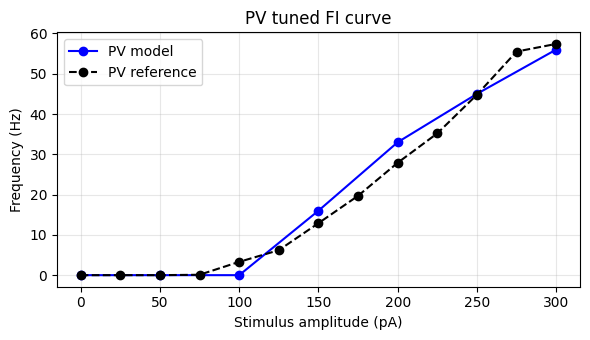

In [12]:
fi_sim_params = {
    "stim_amp": -0.1,      # overwritten per amplitude below; nA
    "stim_delay": 200,     # ms
    "stim_dur": 1000,      # ms
    "h_tstop": 1500,       # ms
    "h_dt": 0.025,         # ms
}
FI_AMP_RANGE = (0, 300, 50)  # pA: start, stop, step
FI_AMPS = list(np.arange(FI_AMP_RANGE[0], FI_AMP_RANGE[1] + FI_AMP_RANGE[2] / 2, FI_AMP_RANGE[2]))

SHOW_TARGET_FI_REFERENCE = True
CUSTOM_FI_REFERENCE = None  # e.g. [(0, 0), (100, 5), (200, 20)]
FI_MODEL_COLOR = context.cell_config.get("color")  # None -> Matplotlib default
FI_REFERENCE_COLOR = None  # None -> black, or gray if the model color is black

EXPORT_FI_FIGURE = False
EXPORT_FI_CSV = False
FI_EXPORT_PATH = context.tune_dir / "notebook_exports" / "step3_active" / f"fi_curve_{context.cell_name.lower()}"

import pandas as pd
from modules.tuning import (
    compare_fi_targets,
    fi_reference_points_from_config,
    fi_reference_points_from_csv,
    fi_rows_from_metrics,
    load_target_config,
    plot_fi_curve,
)

cell = build_tuning_cell(context)
fi_records = run_active_protocol(
    cell=cell,
    sim_params=fi_sim_params,
    sim_amps=FI_AMPS,
)
fi_metrics = active_metric_rows(
    looped_records=fi_records,
    sim_params=fi_sim_params,
    sim_amps=FI_AMPS,
    threshold_mv=active_spike_threshold_mv,
)
fi_rows = fi_rows_from_metrics(fi_metrics)
if "target_config" not in globals():
    target_config = load_target_config(context.tune_dir)

target_config_fi_reference = fi_reference_points_from_config(target_config)
if CUSTOM_FI_REFERENCE is not None:
    target_fi_reference = CUSTOM_FI_REFERENCE
elif "active_target_resolution" in globals() and active_target_resolution.fi_csv_path:
    target_fi_reference = fi_reference_points_from_csv(active_target_resolution.fi_csv_path)
elif "active_target_resolution" in globals() and active_target_resolution.fi_reference_points:
    target_fi_reference = active_target_resolution.fi_reference_points
else:
    target_fi_reference = target_config_fi_reference

print("FI rows:")
for row in fi_rows:
    print(json.dumps(row, indent=2, default=str))

fi_target_comparison = compare_fi_targets(fi_rows, target_fi_reference)
if fi_target_comparison:
    print()
    print("FI target comparison:")
    display(pd.DataFrame(fi_target_comparison))
else:
    print()
    print("No target FI reference available for FI comparison.")

fig_fi = plot_fi_curve(
    fi_rows=fi_rows,
    cell_name=context.cell_name,
    tune_name=context.tune_name,
    bio_reference=target_fi_reference,
    show_bio_reference=SHOW_TARGET_FI_REFERENCE and bool(target_fi_reference),
    model_color=FI_MODEL_COLOR,
    reference_color=FI_REFERENCE_COLOR,
)
plt.show()

if EXPORT_FI_FIGURE:
    save_figure_exports(
        fig_fi,
        export_path=FI_EXPORT_PATH,
        export_formats=EXPORT_FORMATS,
        export_overwrite=EXPORT_OVERWRITE,
        verbose=True,
    )
if EXPORT_FI_CSV:
    save_trace_rows_csv(
        fig_fi,
        FI_EXPORT_PATH.with_suffix(".csv"),
        overwrite=EXPORT_OVERWRITE,
        verbose=True,
    )


## Next Step

After active behavior is acceptable, continue to Step 4 for synapse setup/tuning or Step 5 for current-injection/simulation checks on the prepared tune.